# Contents
> 00. **Imports**: Standard libraries for data processing and geospatial analysis.
> 01. **Merge Roads and Bridges Data:** Loads raw road and bridge data, normalises strings, computes segment lengths from chainage, aggregates bridge condition per LRP, filters to N and R roads, and exports the processed GeoDataFrame.
> 02. **Prepare Criticality:** Loads RMMS traffic data from all `.traffic.htm` files, computes a freight-weighted criticality score per segment, and assigns each LRP to its corresponding road segment via a chainage range join.
> 03. **Prepare Vulnerability:** Loads flood and earthquake shapefiles, performs spatial joins to assign hazard values to each LRP, and computes a final vulnerability score combining bridge condition and maximum environmental hazard.
> 04. **Visualise Vulnerability and Criticality:** Side-by-side geographical maps of bridge vulnerability and road criticality across the network.
> 05. **Data Analysis on Vulnerability:** Top-10 most vulnerable bridges and roads, with distribution plots and discussion of the rank order.
> 06. **Data Analysis on Criticality:** Top-10 most critical road segments and roads, with distribution plots and discussion of the rank order.

---
# 00 Imports

In [14]:
import pandas as pd
import os
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Point

---
# 01 Merge Roads and Bridges Data

In [15]:
raw_df      = pd.read_csv("../data/_roads3.csv")
bridge_info = pd.read_excel("../data/BMMS_overview.xlsx")

df = raw_df.copy()
df["id"] = range(len(df))

# length from km to m
df["length"] = (
    df.groupby("road")["chainage"]
    .diff().abs().fillna(0) * 1000
)

# normalise strings
df["road"] = df["road"].astype(str).str.strip()
df["lrp"]  = df["lrp"].astype(str).str.strip()
df["name"] = df["name"].astype(str).fillna("").str.strip()

# type_simple: Bridge or raw type prefix
df["type_simple"] = df["type"].apply(
    lambda x: "Bridge"
    if isinstance(x, str) and "bridge" in x.lower()
    else str(x).split(" / ")[0].split("%")[0]
)
# merge and aggregate bridge
bridge_info.columns    = bridge_info.columns.str.strip()
bridge_info["LRPName"] = bridge_info["LRPName"].astype(str).str.strip()

def aggregate_bridge_group(group):
    names_str  = " ".join(group["name"].dropna().astype(str).tolist()).upper()
    is_lr_pair = (("(L)" in names_str or " L " in names_str) and
                  ("(R)" in names_str or " R " in names_str))
    return pd.Series({
        "length":    group["length"].median() if is_lr_pair else group["length"].mean(),
        "condition": group["condition"].max(),   # worst condition (D > A)
        "name":      group["name"].iloc[0],
    })

bridge_info_clean = (
    bridge_info.groupby("LRPName", dropna=False)
    .apply(aggregate_bridge_group)
    .reset_index()
    .rename(columns={"length": "length_bmms"})
)

df = df.merge(
    bridge_info_clean,
    left_on="lrp", right_on="LRPName",
    how="left", suffixes=("", "_bmms")
)

mask_bridge       = df["type_simple"] == "Bridge"
mask_has_bmms_len = df["length_bmms"].notna()

df.loc[mask_bridge & mask_has_bmms_len, "length"] = (
    df.loc[mask_bridge & mask_has_bmms_len, "length_bmms"]
)
if "condition_bmms" in df.columns:
    df.loc[mask_bridge, "condition"] = df.loc[mask_bridge, "condition_bmms"]
df.loc[mask_bridge, "condition"] = df.loc[mask_bridge, "condition"].fillna("Unknown")

df = df[df["road"].str.match(r"^[NR]", na=False)].copy()
df['model_type'] = df['type_simple'].apply(
    lambda x: 'bridge' if x == 'Bridge' else 'link'
)

df_roads_bridges = df.sort_values(["road", "chainage"]).reset_index(drop=True)

geometry  = [Point(xy) for xy in zip(df_roads_bridges['lon'], df_roads_bridges['lat'])]
gdf_roads = gpd.GeoDataFrame(df_roads_bridges, geometry=geometry, crs="EPSG:4326")

print(f"  After preprocessing: {len(gdf_roads):,} rows  |  bridges: {mask_bridge.sum()}")


output_path = "../data/roads_after_dataanalysis.csv"
gdf_roads.to_csv(output_path, index=False)

  After preprocessing: 19,512 rows  |  bridges: 9101


---

# 02 Prepare Criticality

## Load Relevant HTM data for N and R roads

In [16]:
col_names = [
    "link_no", "name",
    "start_lrp", "start_offset", "start_chainage",
    "end_lrp", "end_offset", "end_chainage",
    "length_km",
    "heavy_truck", "medium_truck", "small_truck",
    "large_bus", "medium_bus", "micro_bus",
    "utility", "car", "auto_rickshaw", "motorcycle", "bicycle",
    "cycle_rickshaw", "cart",
    "motorized_total", "non_motorized_total",
    "total_aadt", "aadt"
]

data_dir = "../data/traffic/"
all_dfs = []

for filename in os.listdir(data_dir):
    if filename.endswith(".traffic.htm"):
        filepath = os.path.join(data_dir, filename)
        try:
            tables = pd.read_html(filepath, encoding="iso-8859-1", match="List of links")
            df = tables[0].copy()
            df.columns = col_names
            df = df[df["link_no"].str.strip().str.match(r"^[A-Z]+\d+-\d+", na=False)]
            df = df.reset_index(drop=True)
            df["road"] = filename.replace(".traffic.htm", "")
            all_dfs.append(df)
        except Exception as e:
            print(f"Skipped {filename}: {e}")

criticality_df = pd.concat(all_dfs, ignore_index=True)

cols_needed = ['road', 'link_no', 'name',
               'start_lrp', 'start_chainage',
               'end_lrp',   'end_chainage',
               'heavy_truck', 'medium_truck', 'small_truck']
criticality_df = criticality_df[cols_needed].copy()

for col in ['heavy_truck', 'medium_truck', 'small_truck']:
    criticality_df[col] = pd.to_numeric(criticality_df[col], errors='coerce').fillna(0)

criticality_df['start_chainage'] = pd.to_numeric(criticality_df['start_chainage'], errors='coerce')
criticality_df['end_chainage']   = pd.to_numeric(criticality_df['end_chainage'],   errors='coerce')

criticality_df['criticality_score'] = (
    criticality_df['heavy_truck']  * 15 +
    criticality_df['medium_truck'] * 7  +
    criticality_df['small_truck']  * 3
)


In [17]:
criticality_df.head(5)

,road,link_no,name,start_lrp,start_chainage,end_lrp,end_chainage,heavy_truck,medium_truck,small_truck,criticality_score
0,R311,R311-1,BARI More (int with R310) - Ordinance Factory ...,LRPS,0.000,LRP005,4.561,0.0,226.0,343.0,2611.0
1,R203,R203-1,Bhulta(int.with N2)-Araihazar(int.with R114),LRPS,0.000,LRP005,9.100,0.0,204.0,155.0,1893.0
2,R203,R203-2,Araihazar(int.with R114)-Biskandi Ferry ghat,LRP005,9.100,LRP014,18.140,0.0,204.0,155.0,1893.0
3,R203,R203-3,Biskandi Ferry ghat- Bancharampur(int.with Z1043),LRP014,18.140,LRP028,28.552,0.0,204.0,155.0,1893.0
4,R203,R203-4,Bancharampur(int.with Z1043)-Fathepur more(int...,LRP028,28.552,LRP028,32.426,0.0,22.0,20.0,214.0


## Map Roads and Bridges to Road Link number

In [18]:
# Merge op road, dan filteren op chainage range
merged = gdf_roads[['road', 'lrp', 'chainage']].merge(
    criticality_df[['road', 'link_no', 'start_chainage', 'end_chainage', 'criticality_score']],
    on='road', how='left'
)

merged = merged[
    (merged['chainage'] >= merged['start_chainage']) &
    (merged['chainage'] <= merged['end_chainage'])
]

# Één segment per LRP (drop duplicates voor het geval van grenspunten)
segment_per_lrp = (
    merged[['road', 'lrp', 'link_no', 'criticality_score']]
    .drop_duplicates(subset=['road', 'lrp'])
)

# Terugmergen op gdf_roads
gdf_roads = gdf_roads.merge(segment_per_lrp, on=['road', 'lrp'], how='left')

In [19]:
gdf_roads.tail()

,road,chainage,lrp,lat,lon,gap,type,name,id,length,type_simple,LRPName,length_bmms,condition,name_bmms,model_type,geometry,link_no,criticality_score
19507,R890,107.665,LRP106b,22.074888,90.618860,NaN,Culvert,Box Culvert,19507,558.0,Culvert,LRP106b,10.423333,A,KHATABARI CULVERT,link,POINT (90.61886 22.07489),R890-6,2093.0
19508,R890,107.895,LRP107,22.076666,90.619444,NaN,KmPost,Km post missing,19508,230.0,KmPost,NaN,NaN,NaN,NaN,link,POINT (90.61944 22.07667),R890-6,2093.0
19509,R890,108.105,LRP107a,22.078444,90.620166,NaN,Culvert,Box Culvert,19509,210.0,Culvert,LRP107a,20.704444,D,MIABAZAR BOX CULVERT,link,POINT (90.62017 22.07844),R890-6,2093.0
19510,R890,108.455,LRP107b,22.079694,90.617388,NaN,Culvert,Box Culvert,19510,350.0,Culvert,LRP107b,4.475000,B,W LOUSHINIPOR BOX CULVERT,link,POINT (90.61739 22.07969),R890-6,2093.0
19511,R890,108.785,LRPE,22.080888,90.614389,NaN,Others,"End of road at Baburhat, Launch Ghate,Bhola.",19511,330.0,Others,NaN,NaN,NaN,NaN,link,POINT (90.61439 22.08089),R890-6,2093.0


---

# 03 Prepare Vulnerability

## Load Vulnerability Data

In [20]:
# Load Flood Data
gdf_flood = gpd.read_file('../data/flood shapefile/bgd_nhr_floods_sparsso.shp')
# Normalise intensity (Severity mapping: 0→0, Severe→1.0, Moderate→0.6, Low→0.3)
flood_intensity = {0:0.0, 1:1.0, 2:0.6, 3:0.3, 4:1.0, 5:0.6, 6:0.3, 7:1.0, 8:0.6}
gdf_flood['flood_hazard_val'] = gdf_flood['FLOODCAT'].astype(int).map(flood_intensity)

# Load Earthquake Data
gdf_eq = gpd.read_file('../data/earthquake shapefile/bgd_nhr_earthquake_sparsso.shp')
eq_hazard_map = {'I': 1.0, 'II': 0.6, 'III': 0.3}
gdf_eq['eq_hazard_val'] = gdf_eq['ZONE'].map(eq_hazard_map).fillna(0.3)

print(f"Flood: {len(gdf_flood)} polygons; EQ: {len(gdf_eq)} polygons.")

Flood: 4440 polygons; EQ: 142 polygons.


## Spatial Join Vulnerability Data and Roads and Bridges

In [21]:
gdf_roads = gpd.sjoin(gdf_roads, gdf_flood[['geometry', 'flood_hazard_val', 'FLOODCAT']],
                      how='left', predicate='intersects')
if 'index_right' in gdf_roads.columns:
    gdf_roads = gdf_roads.drop(columns=['index_right'])

gdf_roads = gpd.sjoin(gdf_roads, gdf_eq[['geometry', 'eq_hazard_val', 'ZONE']],
                      how='left', predicate='intersects')

gdf_roads = gdf_roads.rename(columns={
    'flood_hazard_val': 'flood_hazard',
    'eq_hazard_val':    'eq_hazard',
    'ZONE':             'eq_zone',
    'FLOODCAT':         'flood_cat'
})

## Vulnerability Scoring

In [22]:
# 1. Map Internal Condition (A-D) to Scores 1-4
cond_to_score = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
gdf_roads['int_cond_score'] = gdf_roads['condition'].map(cond_to_score).fillna(1)

# 2. Assign Multipliers for Environmental Hazards
# Earthquake Seismic Multiplier (Zone I=1.0, II=1.5, III=2.0)
seismic_map = {'I': 1.0, 'II': 1.5, 'III': 2.0}
gdf_roads['seismic_mult'] = gdf_roads['eq_zone'].map(seismic_map).fillna(1.0)

# Flood Hazard Multiplier
# Using  FLOODCAT normalisation logic from the script: max severity = 2.0x
# Mapping flood_hazard (0-1) to a multiplier (1.0 to 2.0)
gdf_roads['flood_mult'] = 1.0 + gdf_roads['flood_hazard']

# 3. Calculate Final Integrated Vulnerability Score
# We take the maximum multiplier between Flood and EQ to find the dominant threat
gdf_roads['max_hazard_mult'] = gdf_roads[['seismic_mult', 'flood_mult']].max(axis=1)

# Final Formula: Internal Condition Score * Maximum Environmental Hazard
gdf_roads['vulnerability_score'] = gdf_roads['int_cond_score'] * gdf_roads['max_hazard_mult']

---

# 04 Visualising Vulnerability and Criticality

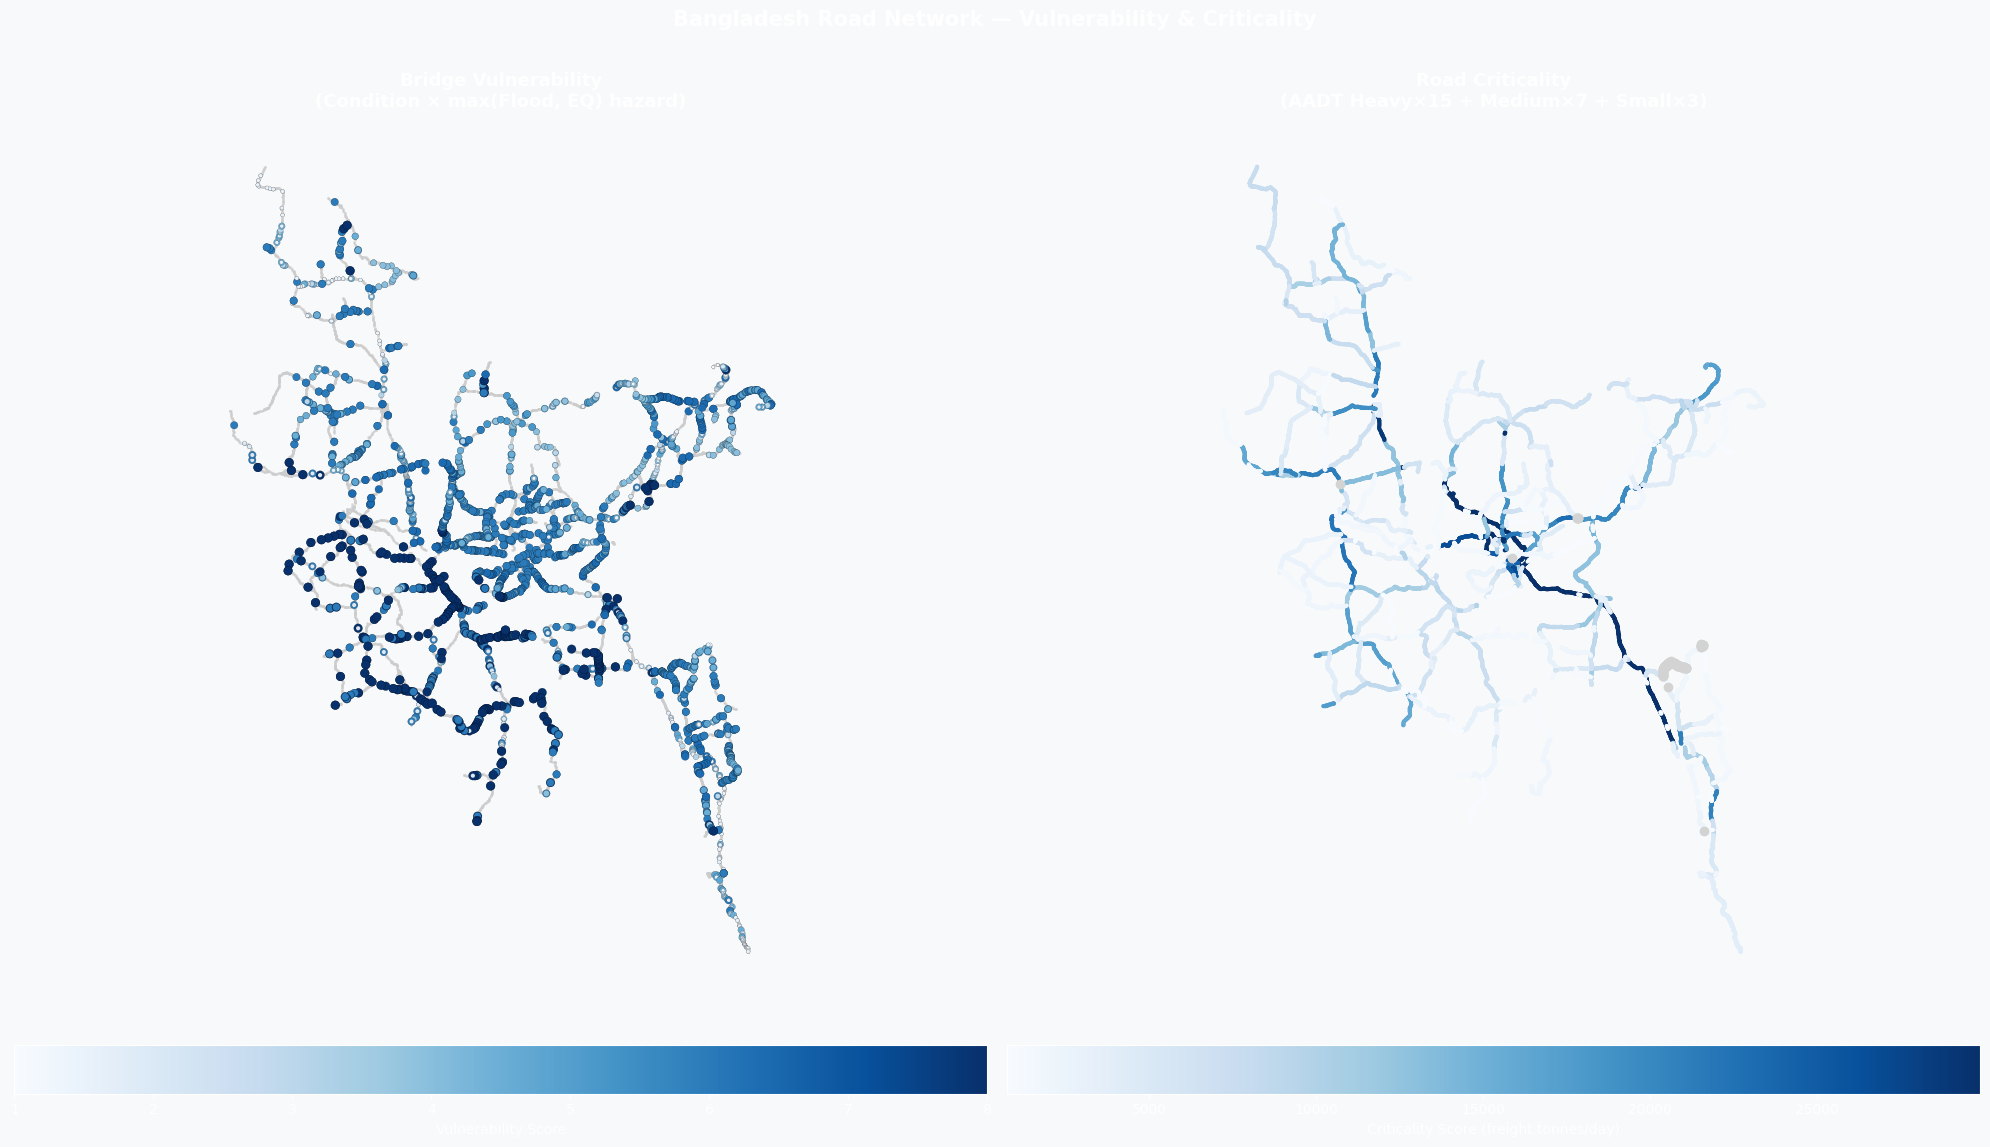

In [23]:
import matplotlib.pyplot as plt

links    = gdf_roads[gdf_roads['model_type'] == 'link']
bridges  = gdf_roads[gdf_roads['model_type'] == 'bridge']

fig, axes = plt.subplots(1, 2, figsize=(20, 12), facecolor='#f8f9fa')

# ── Links subplot helper ─────────────────────────────────────────────────────
LINK_KWARGS = dict(color='#cccccc', markersize=1, alpha=0.5, zorder=1)

# ── Left: Vulnerability ──────────────────────────────────────────────────────
ax = axes[0]
links.plot(ax=ax, **LINK_KWARGS)
bridges.plot(
    ax=ax,
    column='vulnerability_score',
    cmap='Blues',
    markersize=bridges['vulnerability_score'] * 5,
    edgecolor='black', linewidth=0.1,
    legend=True,
    legend_kwds={'label': "Vulnerability Score", 'orientation': "horizontal", 'pad': 0.05},
    zorder=2
)
ax.set_title("Bridge Vulnerability\n(Condition × max(Flood, EQ) hazard)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_axis_off()

# ── Right: Criticality ───────────────────────────────────────────────────────
ax = axes[1]
vmin = gdf_roads['criticality_score'].quantile(0.05)
vmax = gdf_roads['criticality_score'].quantile(0.95)

gdf_roads.plot(
    ax=ax,
    column='criticality_score',
    cmap='Blues',
    markersize=4,
    vmin=vmin, vmax=vmax,
    legend=True,
    legend_kwds={'label': "Criticality Score (freight tonnes/day)",
                 'orientation': "horizontal", 'pad': 0.05},
    missing_kwds={'color': 'lightgrey'},
    zorder=1
)
ax.set_title("Road Criticality\n(AADT Heavy×15 + Medium×7 + Small×3)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_axis_off()

plt.suptitle("Bangladesh Road Network — Vulnerability & Criticality",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# 05 Data Analysis on Vulnerability

### Distribution Overview

/var/folders/8_/w1wzjfs96wx252z5fccfcqtr0000gn/T/ipykernel_79821/3841491759.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=order, patch_artist=True,


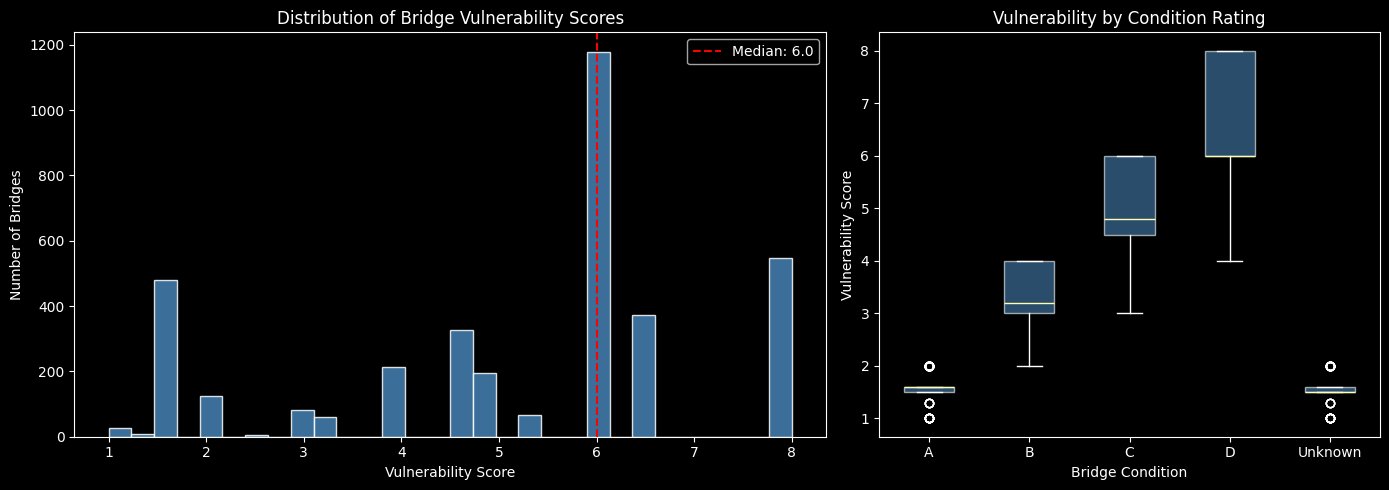

Bridges analysed : 3,689
Score range      : 1.0 – 8.0
Mean / Median    : 5.13 / 6.00


In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

bridges = gdf_roads[gdf_roads['model_type'] == 'bridge'].copy()

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])

# Left: histogram + KDE
ax1 = fig.add_subplot(gs[0])
ax1.hist(bridges['vulnerability_score'].dropna(), bins=30,
         color='steelblue', edgecolor='white', alpha=0.85)
ax1.set_xlabel("Vulnerability Score")
ax1.set_ylabel("Number of Bridges")
ax1.set_title("Distribution of Bridge Vulnerability Scores")
ax1.axvline(bridges['vulnerability_score'].median(), color='red',
            linestyle='--', label=f"Median: {bridges['vulnerability_score'].median():.1f}")
ax1.legend()

# Right: boxplot per condition
ax2 = fig.add_subplot(gs[1])
order = ['A', 'B', 'C', 'D', 'Unknown']
data  = [bridges[bridges['condition'] == c]['vulnerability_score'].dropna()
         for c in order]
ax2.boxplot(data, labels=order, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
ax2.set_xlabel("Bridge Condition")
ax2.set_ylabel("Vulnerability Score")
ax2.set_title("Vulnerability by Condition Rating")

plt.tight_layout()
plt.show()

print(f"Bridges analysed : {len(bridges):,}")
print(f"Score range      : {bridges['vulnerability_score'].min():.1f} – "
      f"{bridges['vulnerability_score'].max():.1f}")
print(f"Mean / Median    : {bridges['vulnerability_score'].mean():.2f} / "
      f"{bridges['vulnerability_score'].median():.2f}")

The **histogram** shows how bridge vulnerability scores are distributed across the network. The histogram shows what the conceptualisation of the vulnerability score resulted in.

The **boxplot** shows how scores vary by condition rating. Since the formula multiplies condition score by a hazard multiplier, a condition D bridge can still score low if it sits in a low-hazard area and vice versa. Wide boxes indicate that location (hazard exposure) adds significant spread within each condition category.

## What drives Vulnerability: condition vs hazard

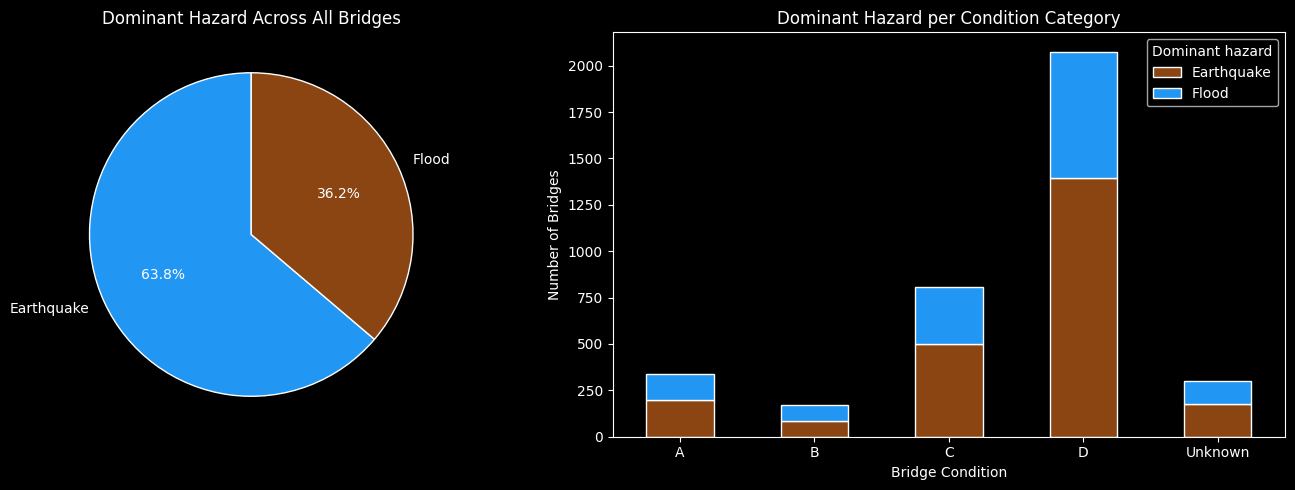

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bridges_temp = bridges.copy()
bridges_temp['dominant_hazard'] = bridges_temp.apply(
    lambda r: 'Flood' if r['flood_mult'] >= r['seismic_mult'] else 'Earthquake', axis=1
)

# Left: pie dominant hazard (keep)
counts = bridges_temp['dominant_hazard'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#8B4513'], startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[0].set_title("Dominant Hazard Across All Bridges")

# Right: stacked bar — condition × dominant hazard
pivot = (bridges_temp
    .groupby(['condition', 'dominant_hazard'])
    .size()
    .unstack(fill_value=0)
    .reindex(['A', 'B', 'C', 'D', 'Unknown'])
)
pivot.plot(kind='bar', stacked=True, ax=axes[1],
           color=['#8B4513', '#2196F3'], edgecolor='white')
axes[1].set_xlabel("Bridge Condition")
axes[1].set_ylabel("Number of Bridges")
axes[1].set_title("Dominant Hazard per Condition Category")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title="Dominant hazard")

plt.tight_layout()
plt.show()

## Top 10 most vulnerable bridges

In [29]:
# ── Top 10 table ─────────────────────────────────────────────────────────────
bridges['dominant_hazard'] = bridges.apply(
    lambda r: 'Flood' if r['flood_mult'] >= r['seismic_mult'] else 'Earthquake', axis=1
)

top10_bridges = (bridges
    .nlargest(10, 'vulnerability_score')
    [['road', 'lrp', 'name', 'condition', 'int_cond_score',
      'flood_mult', 'seismic_mult', 'max_hazard_mult',
      'dominant_hazard', 'vulnerability_score']]
    .reset_index(drop=True)
)
display(top10_bridges)

,road,lrp,name,condition,int_cond_score,flood_mult,seismic_mult,max_hazard_mult,dominant_hazard,vulnerability_score
0,N1,LRP095a,Bridge start,D,4.0,2.0,1.5,2.0,Flood,8.0
1,N1,LRP099b,Bridge end,D,4.0,2.0,1.5,2.0,Flood,8.0
2,N1,LRP105a,Bridge start,D,4.0,2.0,1.5,2.0,Flood,8.0
3,N1,LRP108a,Bridge start,D,4.0,2.0,1.5,2.0,Flood,8.0
4,N1,LRP113b,Bridge end,D,4.0,2.0,1.5,2.0,Flood,8.0
5,N1,LRP168a,Bridge start,D,4.0,2.0,1.5,2.0,Flood,8.0
6,N101,LRP005a,Bridge start,D,4.0,2.0,1.5,2.0,Flood,8.0
7,N101,LRP005b,Bridge end,D,4.0,2.0,1.5,2.0,Flood,8.0
8,N104,LRP022a,Bridge start,D,4.0,1.3,2.0,2.0,Earthquake,8.0
9,N104,LRP022b,Bridge end,D,4.0,1.3,2.0,2.0,Earthquake,8.0


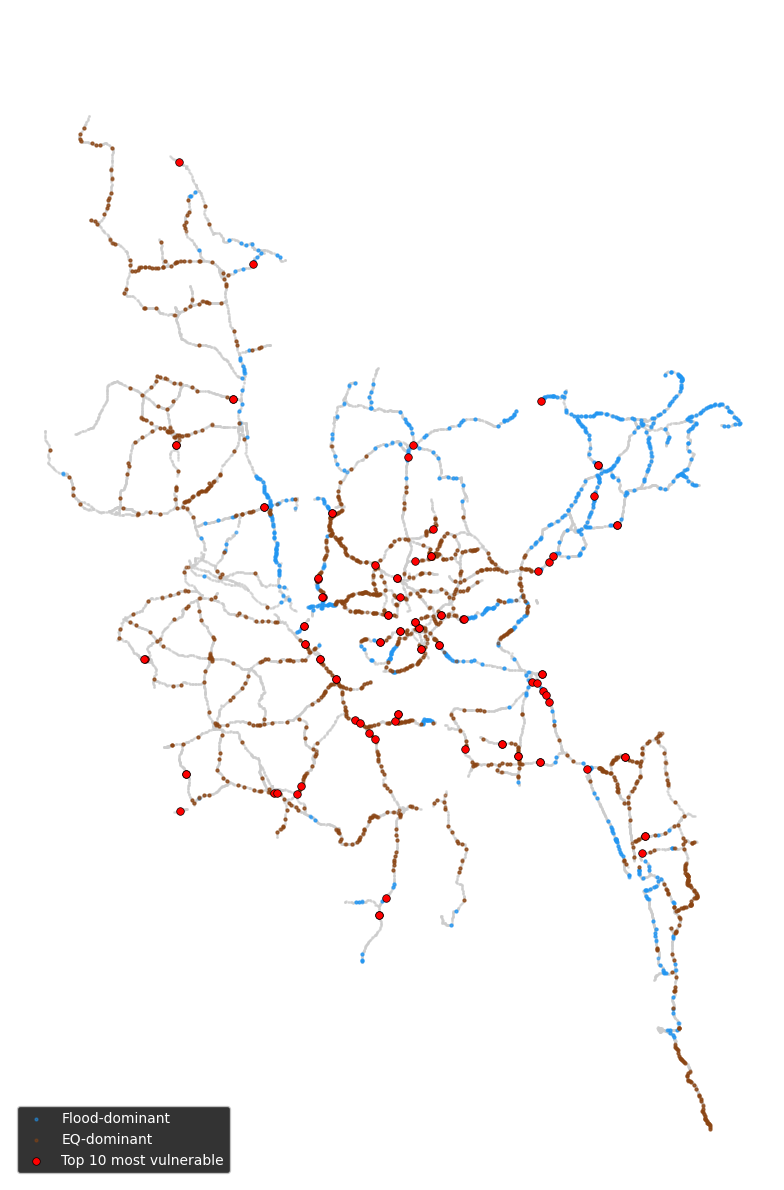

In [31]:
# ── Map: all bridges flood/EQ colored, top 10 highlighted ─────────────────────
links   = gdf_roads[gdf_roads['model_type'] == 'link']
bridges_map = bridges.copy()
bridges_map['dominant_hazard'] = bridges_map.apply(
    lambda r: 'Flood' if r['flood_mult'] >= r['seismic_mult'] else 'Earthquake', axis=1
)
flood_bridges = bridges_map[bridges_map['dominant_hazard'] == 'Flood']
eq_bridges    = bridges_map[bridges_map['dominant_hazard'] == 'Earthquake']
top10_geo     = bridges_map[bridges_map['lrp'].isin(top10_bridges['lrp'])]

fig, ax = plt.subplots(figsize=(10, 12), facecolor='white')
links.plot(ax=ax, color='#cccccc', markersize=1, alpha=0.5, zorder=1)
flood_bridges.plot(ax=ax, color='#2196F3', markersize=4,
                   alpha=0.5, label='Flood-dominant', zorder=2)
eq_bridges.plot(ax=ax, color='#8B4513', markersize=4,
                alpha=0.5, label='EQ-dominant', zorder=2)
top10_geo.plot(ax=ax, color='red', markersize=30,
               edgecolor='black', linewidth=0.5,
               label='Top 10 most vulnerable', zorder=3)

ax.set_title("Bridge Vulnerability — Dominant Hazard\n(red = top 10 most vulnerable)",
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower left')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Top 10 most Vulnerable Roads

In [32]:
# ── Top 10 roads table ────────────────────────────────────────────────────────
road_vulnerability = (bridges
    .groupby('road')
    .agg(
        max_vulnerability  = ('vulnerability_score', 'max'),
        mean_vulnerability = ('vulnerability_score', 'mean'),
        n_bridges          = ('vulnerability_score', 'count'),
        n_flood_dominant   = ('dominant_hazard', lambda x: (x == 'Flood').sum()),
        n_eq_dominant      = ('dominant_hazard', lambda x: (x == 'Earthquake').sum()),
    )
    .reset_index()
    .sort_values('max_vulnerability', ascending=False)
)

top10_roads = road_vulnerability.head(10)
display(top10_roads)

,road,max_vulnerability,mean_vulnerability,n_bridges,n_flood_dominant,n_eq_dominant
0,N1,8.0,2.985804,317,143,174
52,N703,8.0,8.000000,2,0,2
132,R560,8.0,6.428571,21,8,13
120,R506,8.0,5.709091,66,23,43
95,R222,8.0,8.000000,2,2,0
86,R172,8.0,7.000000,4,2,2
84,R170,8.0,5.879070,43,37,6
1,N101,8.0,8.000000,2,2,0
76,R147,8.0,8.000000,2,0,2
75,R145,8.0,8.000000,2,0,2


/var/folders/8_/w1wzjfs96wx252z5fccfcqtr0000gn/T/ipykernel_79821/2150954127.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_roads  = plt.cm.get_cmap('YlOrRd', 10)


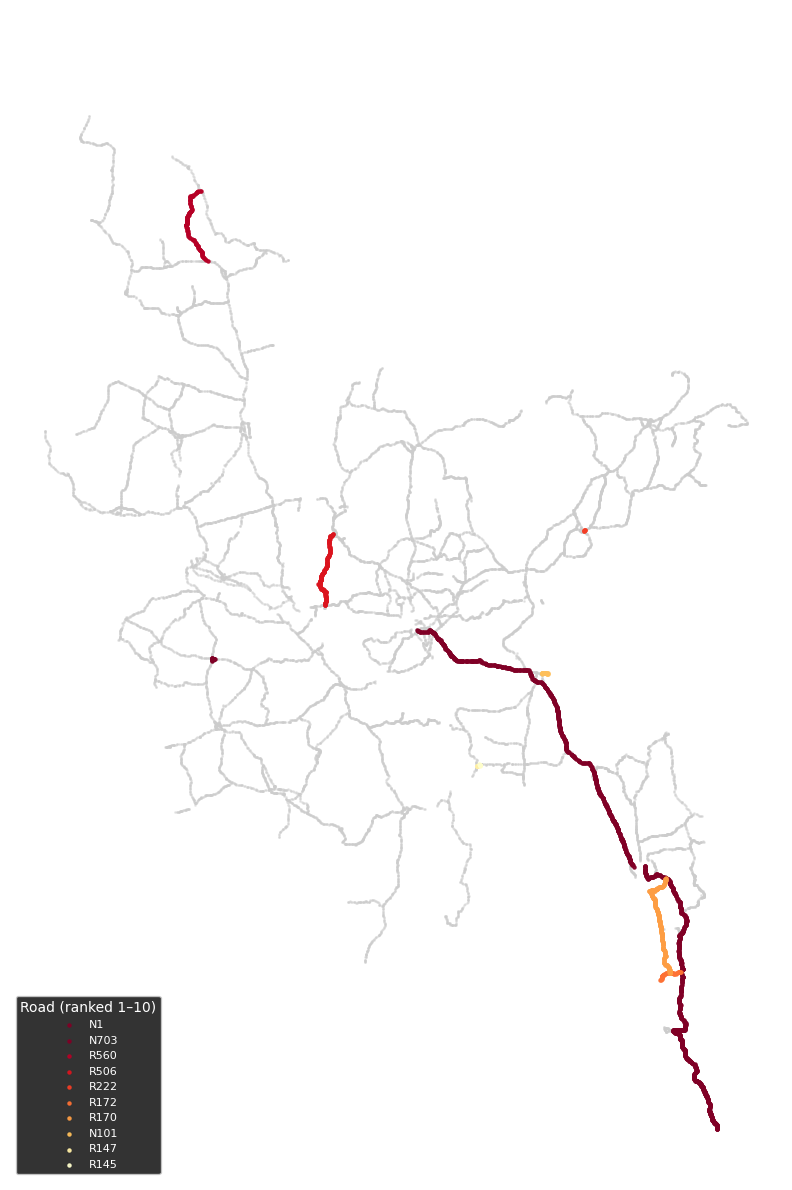

In [33]:
# ── Map: full network grey, top 10 roads highlighted ─────────────────────────
top10_road_names = top10_roads['road'].tolist()

other_roads = gdf_roads[~gdf_roads['road'].isin(top10_road_names)]
highlight   = gdf_roads[gdf_roads['road'].isin(top10_road_names)]

# Color by rank
road_rank   = {road: i for i, road in enumerate(top10_road_names)}
cmap_roads  = plt.cm.get_cmap('YlOrRd', 10)

fig, ax = plt.subplots(figsize=(10, 12), facecolor='white')
other_roads.plot(ax=ax, color='#cccccc', markersize=1, alpha=0.4, zorder=1)

for road in top10_road_names:
    subset = highlight[highlight['road'] == road]
    rank   = road_rank[road]
    subset.plot(ax=ax, color=cmap_roads(1 - rank / 10),
                markersize=5, alpha=0.9, zorder=2, label=road)

ax.set_title("Top 10 Most Vulnerable Roads\n(darker red = higher max vulnerability score)",
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower left', fontsize=8, title="Road (ranked 1–10)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
# 06 Data Analysis on Criticality

# Assumptions

### Data Scope
- Only roads starting with **N** (national) or **R** (regional) are included.
  Z-roads are excluded as they represent local district roads not relevant to the national freight network.

### Bridge Aggregation
- Where multiple bridge records share the same LRP (e.g. left/right carriageway pairs),
  the **median length** is used, as the bridges run in parallel rather than in series.
- For other duplicates at the same LRP, the **mean length** is used.
- The **worst condition rating** (D > C > B > A) is taken when multiple records exist at one LRP,
  as a single failing bridge renders the crossing impassable.

### Vulnerability Scoring
- Bridge condition is mapped to an internal condition score: A=1, B=2, C=3, D=4.
- Road segments without a bridge record receive a baseline score of **1**,
  assuming negligible structural vulnerability in the absence of bridge data.
- Earthquake hazard multipliers follow zoning: Zone I = 1.0×, Zone II = 1.5×, Zone III = 2.0×.
- Flood hazard multiplier is computed as `1.0 + flood_hazard_val`, yielding a range of 1.0–2.0,
  where severe flooding (FLOODCAT = 1) results in the maximum multiplier of 2.0×.
- The **dominant hazard** determines the environmental multiplier: `max(flood_mult, seismic_mult)`.
  This reflects that a segment's vulnerability is dictated by its greatest immediate threat.
- Final formula: `V_score = internal_condition_score × max(flood_mult, seismic_mult)`.

### Criticality Scoring
- Criticality is operationalised as estimated **daily freight tonnage** per road segment,
  using AADT data from the RMMS traffic dataset.
- Only freight vehicles are included: heavy trucks (15 t), medium trucks (7 t), small trucks (3 t).
  Buses and non-motorised traffic are excluded as they do not represent freight economic value.
- Traffic count entries marked **NS** (not surveyed) are treated as **0**,
  assuming no measurable freight flow on those segments.
- Final formula: `Criticality = (AADT_Heavy × 15) + (AADT_Medium × 7) + (AADT_Small × 3)`.
- Segment-level criticality is assigned to individual LRP points via a **chainage range join**.
  LRPs falling exactly on a segment boundary are assigned to the first matching segment.